In [328]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import logging
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, ElasticNet

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.FileHandler("data_pipeline.log"), logging.StreamHandler()],
)
logger = logging.getLogger(__name__)

In [329]:
def read_data(path):
    if path.endswith((".xls", ".xlsx")):
        df = pd.read_excel(path)
    elif path.endswith(".csv"):
        df = pd.read_csv(path)
    else:
        raise ValueError(f"Unsupported file extension at path: {path}")
    if not df.empty:
        print(f"Loaded {len(df)} rows")
    else:
        print(f"Empty dataframe found at path {path}")

    return df

def check_missing_weeks(df):
    df = df.copy()
    df.rename(columns=lambda x: str(x).strip().lower(), inplace=True)
    df["time"]=pd.to_datetime(df["week_end_date"],errors='coerce')
    missing_week_mask=df[(df["price"].isna()) | (df["base_price"].isna())].index
    missing_weeks=df.loc[missing_week_mask,"time"].tolist()
    return missing_weeks,df 

def _clean(df):
    df = df.copy()
    df.rename(columns=lambda x: str(x).strip().lower(), inplace=True)

    if missing_weeks is not None:
       logging.info(f'Missing weeks found...')
       logging.info(f'Replacing null values with forward fill')
       df=df.ffill()
       
    logging.info(f'Cleaning Base Price and Price cols...')
    df=df[(df["base_price"]>0) & (df["price"]>0)]
    logging.info(f'Cleaned dataframe with {len(df)} rows')

    return df

In [330]:
df=read_data('../trans_new.csv')
missing_weeks,df=check_missing_weeks(df)
df=_clean(df)

2026-09-02 20:06:42,851 - INFO - Missing weeks found...
2026-09-02 20:06:42,853 - INFO - Replacing null values with forward fill


Loaded 538643 rows


2026-09-02 20:06:43,026 - INFO - Cleaning Base Price and Price cols...
2026-09-02 20:06:43,100 - INFO - Cleaned dataframe with 538642 rows


In [331]:
logging.info(f'Available columns are {df.columns}')

2026-09-02 20:06:43,119 - INFO - Available columns are Index(['week_end_date', 'store_id', 'upc', 'units', 'visits', 'hhs', 'spend',
       'price', 'base_price', 'feature', 'display', 'tpr_only', 'description',
       'manufacturer', 'category', 'sub_category', 'product_size',
       'store_name', 'address_city_name', 'address_state_prov_code',
       'msa_code', 'seg_value_name', 'parking_space_qty',
       'sales_area_size_num', 'avg_weekly_baskets', 'time'],
      dtype='str')


In [332]:
df["sub_category"].unique()

<StringArray>
[                   'PRETZELS',    'MOUTHWASHES (ANTISEPTIC)',
           'ALL FAMILY CEREAL',                'ADULT CEREAL',
               'PIZZA/PREMIUM',                 'KIDS CEREAL',
 'MOUTHWASH/RINSES AND SPRAYS']
Length: 7, dtype: str

In [333]:
grp=df.groupby(["sub_category","time"]).agg(agg_unit_sales=('units','sum'),
                                        agg_dollar_sales=('spend','sum'),
                                        agg_base_price=('base_price','mean')).reset_index()
grp

,sub_category,time,agg_unit_sales,agg_dollar_sales,agg_base_price
0,ADULT CEREAL,2009-01-14,2195,3996.67,1.806329
1,ADULT CEREAL,2009-01-21,2044,3796.36,1.853924
2,ADULT CEREAL,2009-01-28,2106,3910.53,1.850759
3,ADULT CEREAL,2009-02-04,2370,4404.07,1.851772
4,ADULT CEREAL,2009-02-11,2237,4026.03,1.808462
...,...,...,...,...,...
1087,PRETZELS,2011-12-07,17903,34287.20,2.433041
1088,PRETZELS,2011-12-14,19765,38672.06,2.442303
1089,PRETZELS,2011-12-21,22774,44313.59,2.439408
1090,PRETZELS,2011-12-28,19613,38407.18,2.435625


In [334]:
forecast_list = ["agg_base_price", "agg_dollar_sales", "agg_unit_sales"]

models = {}
forecasts = {}

for var in forecast_list:

    data = grp[grp["sub_category"] == "ADULT CEREAL"].copy()
    data = data.rename(columns={"time": "ds", var: "y"})

    cols_to_drop = ["sub_category"] + [x for x in forecast_list if x != var]
    data = data.drop(columns=cols_to_drop, errors="ignore")

    models[var]=Prophet(  yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative")
    models[var].fit(data)

    future = models[var].make_future_dataframe(periods=156, freq="W")
    forecasts[var] = models[var].predict(future)


2026-09-02 20:06:43,221 - INFO - Chain [1] start processing
2026-09-02 20:06:43,264 - INFO - Chain [1] done processing
2026-09-02 20:06:43,323 - INFO - Chain [1] start processing
2026-09-02 20:06:43,341 - INFO - Chain [1] done processing
2026-09-02 20:06:43,397 - INFO - Chain [1] start processing
2026-09-02 20:06:43,425 - INFO - Chain [1] done processing


In [335]:
forecast=pd.DataFrame(forecasts["agg_unit_sales"])[["ds","yhat"]].tail(156)
forecast["year"]=forecast["ds"].dt.year
forecast.pivot_table(
    index="year", values="yhat", aggfunc="sum"
).round(4)

,yhat
year,
2012,324202.3847
2013,305552.6119
2014,286900.8547


In [336]:
df.columns

Index(['week_end_date', 'store_id', 'upc', 'units', 'visits', 'hhs', 'spend',
       'price', 'base_price', 'feature', 'display', 'tpr_only', 'description',
       'manufacturer', 'category', 'sub_category', 'product_size',
       'store_name', 'address_city_name', 'address_state_prov_code',
       'msa_code', 'seg_value_name', 'parking_space_qty',
       'sales_area_size_num', 'avg_weekly_baskets', 'time'],
      dtype='str')

In [337]:
def train_linear_model(df, group_cols, sub_category):
    df = df.copy()
    grp = (
        df.groupby(group_cols)
        .agg(
            agg_unit_sales=("units", "sum"),
            agg_dollar_sales=("spend", "sum"),
            agg_base_price=("base_price", "mean"),
        )
        .reset_index()
    )

    data = grp[grp["sub_category"] == sub_category].copy()

    X = data[["agg_base_price", "agg_dollar_sales"]]
    y = data["agg_unit_sales"]

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    model = ElasticNet(alpha=1,l1_ratio=0.75)
    model.fit(X_scaled, y)

    return model, {"slope": model.coef_, "intercept": model.intercept_}


trained_lr_model, coef_dict = train_linear_model(
    df=df, group_cols=["sub_category", "time"], sub_category="ADULT CEREAL"
)

In [338]:
forecast_input = pd.DataFrame(
    {
        "agg_base_price": forecasts["agg_base_price"]["yhat"],
        "agg_dollar_sales": forecasts["agg_dollar_sales"]["yhat"],
    }
)
scaler = StandardScaler()
forecast_input=pd.DataFrame(scaler.fit_transform(forecast_input), columns=forecast_input.columns)
forecast_input

,agg_base_price,agg_dollar_sales
0,-3.640762,-2.687020
1,-3.494230,-2.328928
2,-3.384062,-1.911599
3,-3.299998,-1.585491
4,-3.216546,-1.515062
...,...,...
307,1.349678,-1.459713
308,1.363574,-1.355900
309,1.364425,-1.450361
310,1.347524,-1.665751


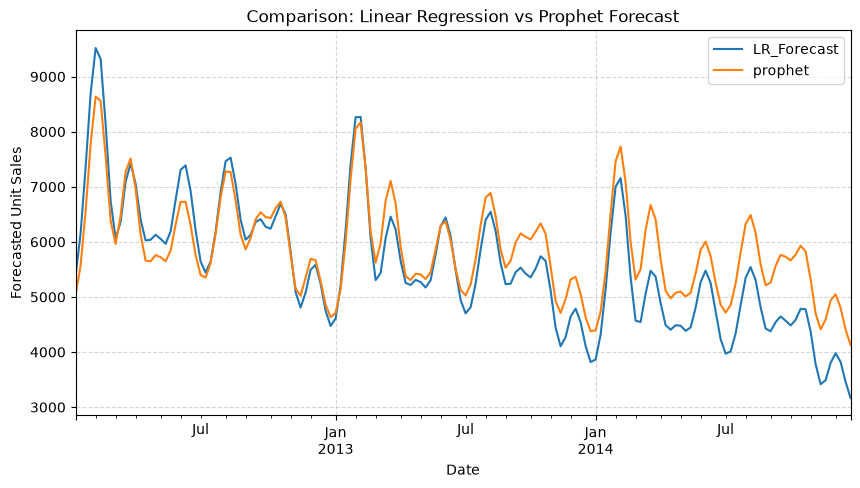

In [339]:
unit_sales_forecast=pd.DataFrame(trained_lr_model.predict(forecast_input),columns=['LR_Forecast'])
unit_sales_forecast["prophet"]=forecasts["agg_unit_sales"]["yhat"]
unit_sales_forecast["time"]=forecasts["agg_unit_sales"]["ds"]
unit_sales_forecast.tail(156).set_index("time")[["LR_Forecast", "prophet"]].plot(
    kind="line", figsize=(10, 5)
)


plt.title("Comparison: Linear Regression vs Prophet Forecast")
plt.ylabel("Forecasted Unit Sales")
plt.xlabel("Date")
plt.grid(True, linestyle="--", alpha=0.5)  
plt.show()


In [341]:
unit_sales_forecast["year"]=unit_sales_forecast["time"].dt.year
pivot=unit_sales_forecast.pivot_table(
    index="year", values=["LR_Forecast","prophet"], aggfunc="sum"
).round(4)
pivot["LR_YoY"]=pivot["LR_Forecast"].pct_change()*100
pivot["prophet_YoY"]=pivot["prophet"].pct_change()*100
pivot.round(2)

,LR_Forecast,prophet,LR_YoY,prophet_YoY
year,,,,
2009,253778.69,257043.61,NaN,NaN
2010,420509.82,357594.61,65.70,39.12
2011,379829.93,343013.24,-9.67,-4.08
2012,339561.67,329120.71,-10.60,-4.05
2013,289437.99,305552.61,-14.76,-7.16
2014,244491.90,286900.85,-15.53,-6.10
